<a href="https://colab.research.google.com/github/zshaan25/CodeAlpha_Handwritten_Character_Recognition/blob/main/Handwritten_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching MNIST dataset...
Training data shape: (60000, 28, 28, 1)

Training CNN for Handwritten Character Recognition...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9041 - loss: 0.3109 - val_accuracy: 0.9789 - val_loss: 0.0684
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9683 - loss: 0.1052 - val_accuracy: 0.9846 - val_loss: 0.0425
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9769 - loss: 0.0794 - val_accuracy: 0.9890 - val_loss: 0.0316
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9804 - loss: 0.0654 - val_accuracy: 0.9892 - val_loss: 0.0350
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9836 - loss: 0.0554 - val_accuracy: 0.9902 - val_loss: 0.0275
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0487 - val_accuracy: 0.9909 - val_loss: 0.0285
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0453 - val_accuracy: 0.9923 -

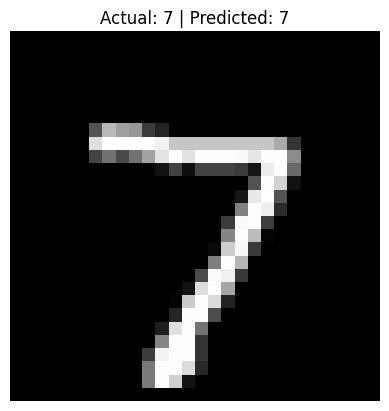

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Load the Dataset
print("Fetching MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Preprocess the Image Data
# CNNs expect 4D tensors: (batch_size, height, width, channels)
# Grayscale images have 1 channel. We reshape the data to include it.
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values from [0, 255] to [0, 1] to help the network learn faster
X_train /= 255.0
X_test /= 255.0

print(f"Training data shape: {X_train.shape}")

# 3. Architect the 2D CNN
model = Sequential([
    # First Convolutional Block
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block for deeper feature extraction
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # Prevent overfitting

    # Flatten the 2D arrays for fully connected layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer: 10 units for digits 0-9
    Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 5. Train the Network
print("\nTraining CNN for Handwritten Character Recognition...")
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(X_test, y_test),
                    verbose=1)

# 6. Evaluate Performance
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- Final Model Evaluation ---")
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

# 7. Bonus: Visualizing a Prediction (Great for your LinkedIn video!)
def visualize_prediction(index):
    image = X_test[index]
    actual_label = y_test[index]

    # Predict
    prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)
    predicted_label = np.argmax(prediction)

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

# Run visualization on the first test image
print("Visualizing a sample prediction...")
visualize_prediction(0)